# SigAlg's `L2.proj` method

In [1]:
# If running in Google Colab, uncomment the line below and run this cell first.
# Also, for Mac+Chrome users, beware of a known bug with LaTeX redering in Colab: https://github.com/googlecolab/colabtools/issues/3192

# !pip install sigalg

The `L2.proj` method in SigAlg computes the *orthogonal projection* of a random variable onto a subspace of the $L^2$-Hilbert space. The API reference is [here](https://johnmyers-phd.com/sigalg/api/modules/l2/#sigalg.l2.L2.proj).

## Mathematical definition

Let $X \in L^2(\Omega, \mathcal{F}, P)$ be a random variable and let $V \subset L^2(\Omega, \mathcal{F}, P)$ be a finite-dimensional subspace spanned by random variables $Y_1, Y_2, \ldots, Y_k$. The *orthogonal projection* of $X$ onto $V$ is the unique random variable $\text{proj}_V(X) \in V$ such that

$$
X - \text{proj}_V(X) \perp V,
$$

meaning $\langle X - \text{proj}_V(X), Y \rangle = 0$ for all $Y \in V$.

The projection has the following key properties:

1. *Closest point property*: $\text{proj}_V(X)$ minimizes the $L^2$-distance from $X$ to $V$:
   $$
   \|X - \text{proj}_V(X)\| = \min_{Y \in V} \|X - Y\|.
   $$

2. *Orthogonal decomposition*: We can write
   $$
   X = \text{proj}_V(X) + (X - \text{proj}_V(X)),
   $$
   where the two terms are orthogonal.

3. *Pythagorean theorem*:
   $$
   \|X\|^2 = \|\text{proj}_V(X)\|^2 + \|X - \text{proj}_V(X)\|^2.
   $$

If $V$ is spanned by $Y_1, \ldots, Y_k$, then

$$
\text{proj}_V(X) = \sum_{i=1}^k c_i Y_i,
$$

where the coefficients $c_1, \ldots, c_k$ are determined by solving the *normal equations*:

$$
\langle \text{proj}_V(X), Y_i \rangle = \langle X, Y_i \rangle \quad \text{for } i = 1, \ldots, k.
$$

This is equivalent to least squares regression when viewed as fitting $X$ with a linear combination of $Y_1, \ldots, Y_k$.

## API examples


### Basic projection

We begin by setting up a probability space and creating an $L^2$ space.

In [2]:
from sigalg.core import ProbabilityMeasure, RandomVariable, SampleSpace, SigmaAlgebra
from sigalg.l2 import L2
import numpy as np

Omega = SampleSpace().from_sequence(size=4)

F = SigmaAlgebra(sample_space=Omega, name="F").from_dict(
    {
        0: 0,
        1: 1,
        2: 0,
        3: 1,
    }
)

P = ProbabilityMeasure(sample_space=Omega).from_dict(
    {
        0: 0.1,
        1: 0.15,
        2: 0.45,
        3: 0.3,
    }
)

H = L2(sample_space=Omega, sigma_algebra=F, probability_measure=P)

Create a random variable $X$ and project it onto the subspace spanned by a single basis vector.

In [3]:
X = RandomVariable(domain=Omega, name="X").from_dict(
    {
        0: 2,
        1: -3,
        2: 2,
        3: -3,
    }
)

# Get one basis vector
basis = H.basis
phi_0 = list(basis.values())[0]

# Project X onto the 1-dimensional subspace spanned by phi_0
X_proj, coeffs, dim = H.proj(X, [phi_0])

print(f"Original X: {X}")
print(f"\nProjection: {X_proj}")
print(f"\nCoefficients: {coeffs}")
print(f"Dimension of subspace: {dim}")

Original X: Random variable 'X':
        X
sample   
0       2
1      -3
2       2
3      -3

Projection: Random variable 'X_proj':
        X_proj
sample        
0          2.0
1          0.0
2          2.0
3          0.0

Coefficients: [1.4832397]
Dimension of subspace: 1


The method returns a tuple `(projected_rv, coefficients, dimension)` where:
- `projected_rv` is the orthogonal projection $\text{proj}_V(X)$
- `coefficients` is a list of the coefficients $c_i$ in the linear combination
- `dimension` is the dimension of the subspace $V$

### Verifying orthogonality

The residual $X - \text{proj}_V(X)$ should be orthogonal to the subspace $V$.

In [4]:
residual = X - X_proj

# Check orthogonality to phi_0
inner_prod = H.inner(residual, phi_0)
print(f"⟨X - proj(X), φ_0⟩ = {inner_prod:.10f}")
print(f"Orthogonal: {abs(inner_prod) < 1e-10}")

⟨X - proj(X), φ_0⟩ = 0.0000000000
Orthogonal: True


### Projection minimizes distance

The projection is the closest point in the subspace to $X$. Let's verify this by comparing distances.

In [5]:
# Distance from X to its projection
distance_to_proj = H.metric(X, X_proj)

# Distance to other elements in the subspace
other_elements = [0.5 * phi_0, 2.0 * phi_0, -1.5 * phi_0]

print(f"Distance from X to projection: {distance_to_proj:.6f}")
print("\nDistances to other elements in subspace:")
for i, elem in enumerate(other_elements):
    dist = H.metric(X, elem)
    print(f"  {i+1}. Distance: {dist:.6f} (≥ {distance_to_proj:.6f})")

Distance from X to projection: 2.012461

Distances to other elements in subspace:
  1. Distance: 2.239813 (≥ 2.012461)
  2. Distance: 2.077749 (≥ 2.012461)
  3. Distance: 3.598572 (≥ 2.012461)


### Projection onto multiple basis vectors

We can project onto the entire $L^2$ space by using all basis vectors.

In [6]:
# Project onto the full L2 space
all_basis = list(H.basis.values())
X_proj_full, coeffs_full, dim_full = H.proj(X, all_basis)

print(f"Original X: {X}")
print(f"\nProjection onto full L²: {X_proj_full}")
print(f"\nAre they equal? {X == X_proj_full}")
print(f"Dimension: {dim_full}")

Original X: Random variable 'X':
        X
sample   
0       2
1      -3
2       2
3      -3

Projection onto full L²: Random variable 'X_proj':
        X_proj
sample        
0          2.0
1         -3.0
2          2.0
3         -3.0

Are they equal? True
Dimension: 2


Since $X$ is already $\mathcal{F}$-measurable (i.e., $X \in L^2(\Omega, \mathcal{F}, P)$), projecting onto the full space returns $X$ itself.

### Polynomial regression

One of the most important applications of orthogonal projection is *polynomial regression*. Given data $(X, Y)$, we can fit a polynomial $p(X) = c_0 + c_1 X + c_2 X^2 + \cdots + c_k X^k$ to $Y$ by projecting $Y$ onto the subspace spanned by $1, X, X^2, \ldots, X^k$.

In [7]:
# Create a larger sample space for regression
n = 20
Omega_large = SampleSpace().from_sequence(size=n)
P_uniform = ProbabilityMeasure.uniform(sample_space=Omega_large)
H_large = L2(sample_space=Omega_large, probability_measure=P_uniform)

# Create synthetic data: Y = 2 + 3X - X² + noise
np.random.seed(42)
x_vals = np.linspace(-2, 2, n)
y_vals = 2 + 3*x_vals - x_vals**2 + 0.5 * np.random.randn(n)

X_reg = RandomVariable(domain=Omega_large, name="X").from_numpy(x_vals)
Y_reg = RandomVariable(domain=Omega_large, name="Y").from_numpy(y_vals)

print(f"Created {n} data points for regression")

Created 20 data points for regression


Fit a cubic polynomial $Y \approx c_0 + c_1 X + c_2 X^2 + c_3 X^3$ using orthogonal projection.

In [8]:
# Create polynomial basis: 1, X, X², X³
one = RandomVariable(domain=Omega_large, name="1").from_constant(1)
polynomial_basis = [one, X_reg, X_reg**2, X_reg**3]

# Project Y onto the polynomial subspace
Y_fit, coeffs_poly, dim_poly = H_large.proj(Y_reg, polynomial_basis)

print(f"Polynomial coefficients:")
print(f"  c_0 (constant): {coeffs_poly[0]:.4f}")
print(f"  c_1 (linear):   {coeffs_poly[1]:.4f}")
print(f"  c_2 (quadratic): {coeffs_poly[2]:.4f}")
print(f"  c_3 (cubic):    {coeffs_poly[3]:.4f}")

# The fitted polynomial is: Y_fit = c_0 + c_1*X + c_2*X² + c_3*X³
print(f"\nFitted polynomial: Y ≈ {coeffs_poly[0]:.2f} + {coeffs_poly[1]:.2f}X + {coeffs_poly[2]:.2f}X² + {coeffs_poly[3]:.2f}X³")

Polynomial coefficients:
  c_0 (constant): 1.9449
  c_1 (linear):   2.5534
  c_2 (quadratic): -1.0207
  c_3 (cubic):    0.0795

Fitted polynomial: Y ≈ 1.94 + 2.55X + -1.02X² + 0.08X³


Compute the $R^2$ (coefficient of determination) to measure goodness of fit.

In [9]:
from sigalg.core import Operators

E = Operators.expectation
Y_reg.probability_measure = P_uniform

# Total sum of squares: ‖Y - Ȳ‖²
Y_mean = E(Y_reg)
SS_tot = H_large.norm(Y_reg - Y_mean)**2

# Residual sum of squares: ‖Y - Ŷ‖²
SS_res = H_large.norm(Y_reg - Y_fit)**2

# R² = 1 - SS_res/SS_tot
R_squared = 1 - SS_res / SS_tot

print(f"R² = {R_squared:.4f}")

R² = 0.9906


Visualize the polynomial fit.

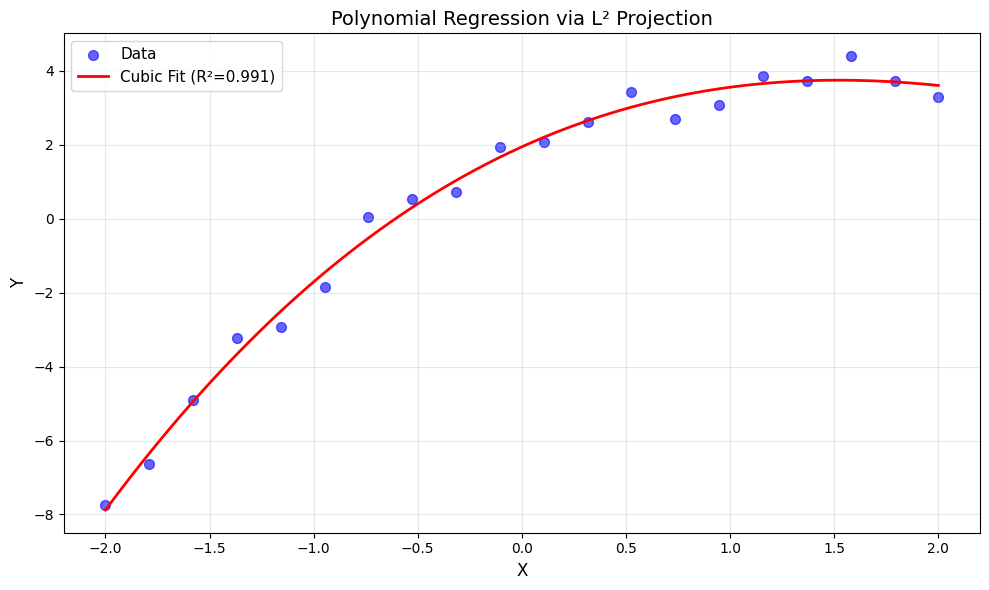

In [10]:
import matplotlib.pyplot as plt

# Generate smooth curve for plotting
x_smooth = np.linspace(x_vals.min(), x_vals.max(), 100)
y_smooth = coeffs_poly[0] + coeffs_poly[1]*x_smooth + coeffs_poly[2]*x_smooth**2 + coeffs_poly[3]*x_smooth**3

plt.figure(figsize=(10, 6))
plt.scatter(X_reg.data, Y_reg.data, color='blue', alpha=0.6, label='Data', s=50)
plt.plot(x_smooth, y_smooth, color='red', linewidth=2, label=f'Cubic Fit (R²={R_squared:.3f})')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Polynomial Regression via L² Projection', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Trigonometric polynomial fitting

We can also fit *trigonometric polynomials* (Fourier series) by projecting onto a subspace spanned by $\cos(nX)$ and $\sin(nX)$ for various $n$.

In [11]:
# Create synthetic periodic data
np.random.seed(123)
x_trig = np.linspace(0, 2*np.pi, n)
y_trig = 2*np.sin(x_trig) + 0.5*np.cos(2*x_trig) + 0.3 * np.random.randn(n)

X_trig = RandomVariable(domain=Omega_large, name="X").from_numpy(x_trig)
Y_trig = RandomVariable(domain=Omega_large, name="Y").from_numpy(y_trig)

print(f"Created {n} data points for trigonometric fitting")

Created 20 data points for trigonometric fitting


Fit a trigonometric polynomial $Y \approx \sum_{n=1}^{4} a_n \cos(nX) + b_n \sin(nX)$.

In [12]:
# Create trigonometric basis
trig_basis = []
for n in range(1, 5):
    cos_n = RandomVariable(domain=Omega_large, name=f"cos({n}X)").from_numpy(np.cos(n * x_trig))
    sin_n = RandomVariable(domain=Omega_large, name=f"sin({n}X)").from_numpy(np.sin(n * x_trig))
    trig_basis.extend([cos_n, sin_n])

# Project Y onto the trigonometric subspace
Y_trig_fit, coeffs_trig, dim_trig = H_large.proj(Y_trig, trig_basis)

print(f"Trigonometric coefficients:")
for n in range(1, 5):
    a_n = coeffs_trig[2*(n-1)]
    b_n = coeffs_trig[2*(n-1) + 1]
    print(f"  n={n}: a_{n} = {a_n:.4f}, b_{n} = {b_n:.4f}")

Trigonometric coefficients:
  n=1: a_1 = 0.1312, b_1 = 1.8496
  n=2: a_2 = 0.5645, b_2 = -0.1109
  n=3: a_3 = -0.0358, b_3 = -0.1142
  n=4: a_4 = -0.1510, b_4 = -0.0192


Visualize the trigonometric fit.

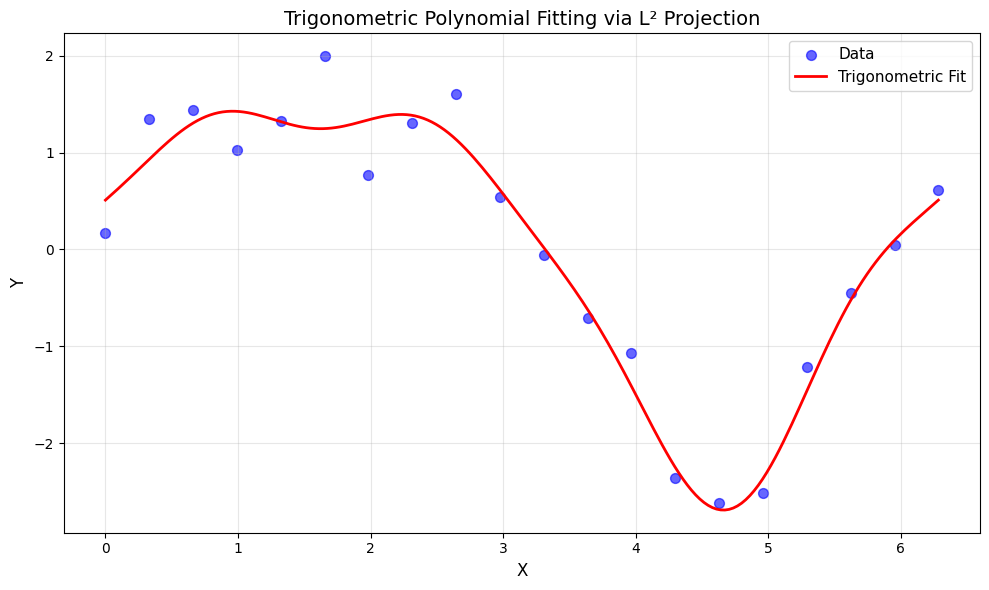

In [13]:
# Generate smooth curve
x_trig_smooth = np.linspace(0, 2*np.pi, 200)
y_trig_smooth = np.zeros_like(x_trig_smooth)
for n in range(1, 5):
    a_n = coeffs_trig[2*(n-1)]
    b_n = coeffs_trig[2*(n-1) + 1]
    y_trig_smooth += a_n * np.cos(n * x_trig_smooth) + b_n * np.sin(n * x_trig_smooth)

plt.figure(figsize=(10, 6))
plt.scatter(X_trig.data, Y_trig.data, color='blue', alpha=0.6, label='Data', s=50)
plt.plot(x_trig_smooth, y_trig_smooth, color='red', linewidth=2, label='Trigonometric Fit')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Trigonometric Polynomial Fitting via L² Projection', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Connection to conditional expectation

The *conditional expectation* $E(X \mid \mathcal{G})$ is the orthogonal projection of $X$ onto the subspace $L^2(\Omega, \mathcal{G}, P)$ of $\mathcal{G}$-measurable random variables.

Let's verify this fundamental connection.

In [14]:
# Change the ambient sigma-algebra on H to the power-set of Omega
H.sigma_algebra = SigmaAlgebra.power_set(sample_space=Omega)

# Create a finer sigma-algebra G
G = SigmaAlgebra(sample_space=Omega, name="G").from_dict(
    {
        0: 0,
        1: 0,
        2: 1,
        3: 1,
    }
)

# Create L2 space with respect to G
H_G = L2(sample_space=Omega, sigma_algebra=G, probability_measure=P)

# Create a random variable
X_cond = RandomVariable(domain=Omega, name="X").from_dict(
    {
        0: 3,
        1: 5,
        2: -2,
        3: 1,
    }
)
X_cond.probability_measure = P

Compute the conditional expectation using the `expectation` method.

In [15]:
# Conditional expectation E(X|G)
E_X_given_G = Operators.expectation(X_cond, G)
print(f"E(X|G) via expectation method: {E_X_given_G}")

E(X|G) via expectation method: Random variable 'E(X|G)':
        E(X|G)
sample        
0          4.2
1          4.2
2         -0.8
3         -0.8


Compute the same quantity as a projection onto $L^2(\Omega, \mathcal{G}, P)$.

In [16]:
# Project X onto L²(Ω, G, P) using the orthonormal basis of G
basis_G = list(H_G.basis.values())
X_proj_G, coeffs_G, dim_G = H.proj(X_cond, basis_G)

print(f"Projection onto L²(Ω,G,P): {X_proj_G}")
print(f"\nAre they equal? {E_X_given_G == X_proj_G}")

Projection onto L²(Ω,G,P): Random variable 'X_proj':
        X_proj
sample        
0          4.2
1          4.2
2         -0.8
3         -0.8

Are they equal? True


Verify that $E(X \mid \mathcal{G})$ minimizes the $L^2$ distance from $X$ to the set of $\mathcal{G}$-measurable random variables.

In [17]:
# Distance from X to E(X|G)
distance_to_cond_exp = H.metric(X_cond, E_X_given_G)

# Try another G-measurable random variable
other_G_measurable = RandomVariable(domain=Omega).from_dict(
    {
        0: 2,
        1: 2,
        2: -1,
        3: -1,
    }
)
distance_to_other = H.metric(X_cond, other_G_measurable)

print(f"Distance from X to E(X|G): {distance_to_cond_exp:.6f}")
print(f"Distance from X to another G-measurable RV: {distance_to_other:.6f}")
print(f"\nConditional expectation minimizes distance: {distance_to_cond_exp <= distance_to_other}")

Distance from X to E(X|G): 1.363818
Distance from X to another G-measurable RV: 1.760682

Conditional expectation minimizes distance: True
